# CAM-MPAS DYAMOND: Vertical Cloud Structure

This notebook visualizes the vertical (altitude vs. latitude) structure of deep convective storms
in CAM-MPAS DYAMOND simulations.

**What it does:**
- Surveys daily 2D output (h0a files) to locate strong deep convective events using column-integrated
  cloud ice water path (TGCLDIWP) as a proxy.
- Loads a single 3-hourly 3D snapshot (h1i file) for a selected event.
- Extracts a narrow longitude band of model columns and sorts them by latitude to form a
  "curtain" (latitude vs. height cross-section).
- Produces dual-colormap pcolormesh plots: green for cloud liquid water, pink/purple for cloud ice.
- Overlays temperature contours and a tropopause proxy (T = 200 K isotherm).

**Case and grid:** Set  in the configuration cell below. The correct  is
looked up automatically from .

**Data source:** 


In [2]:
from pathlib import Path
import yaml
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import uxarray as ux

# ── CONFIGURATION ──────────────────────────────────────────────────────────────
CASE = "c124_ecomip-p1-golden_clubbmf.002" # "c124_dyamond1_lr_clubbmf"
ARCHIVE = Path("/glade/campaign/cesm/km-scale/archive")

# Cross-section parameters (update after running the storm survey below)
TARGET_DATE    = "2016-08-01"  # YYYY-MM-DD
TARGET_SECONDS = 10800         # seconds since midnight; check snapshot_files in Cell 3 for valid values
LON_CENTER     = 205.0         # degrees (0-360); near eastern Pacific ITCZ
LON_HALF_WIDTH = 2.0           # degrees; widen to ~5 if too few cells
LAT_RANGE      = (5, 35)       # (south, north) latitude window
ALT_MAX        = 18000         # m -- cap y-axis to show troposphere + lower strat

# Updated values after survey:
#lo res case: 2016-09-04 12:00      12.3     20.1
# ecomip: 2024-09-03 11:30 15.7 43.5  13.5188

TARGET_DATE = "2024-09-03"
TARGET_SECONDS = int(11.5*3600)
LON_CENTER = 43.5

# ── GRID FILE & STREAM LOOKUP ──────────────────────────────────────────────────
_cfg_path = Path("/glade/u/home/brianpm/Code/hacknostics/util/km_scale_cases.yaml")
with open(_cfg_path) as _f:
    _cfg = yaml.safe_load(_f)

_case_cfg = _cfg["cases"].get(CASE)
if _case_cfg is None:
    raise ValueError(f"Case {CASE!r} not found in {_cfg_path}. Add it to km_scale_cases.yaml.")
_grid_key = _case_cfg["grid"]
_grid_root = Path(_cfg["grid_files_root"])
_grid_filename = _cfg["grids"][_grid_key]["filename"]
GRID_FILE = _grid_root / _grid_filename

# Stream names vary by case — read from YAML rather than hardcoding
SURVEY_STREAM   = _case_cfg["survey_stream"]    # stream that has TGCLDIWP (storm survey)
SNAPSHOT_STREAM = _case_cfg["snapshot_stream"]  # stream that has CLDLIQ, CLDICE, Z3, T (curtain)

print(f"Case:            {CASE}")
_grid_res = _cfg["grids"][_grid_key]["resolution_km"]
print(f"Grid:            {_grid_key}  ({_grid_res} km)")
print(f"Grid file:       {GRID_FILE}")
print(f"Survey stream:   {SURVEY_STREAM}")
print(f"Snapshot stream: {SNAPSHOT_STREAM}")


Case:            c124_ecomip-p1-golden_clubbmf.002
Grid:            mpasa3p75  (3.75 km)
Grid file:       /glade/campaign/cesm/cesmdata/inputdata/share/meshes/mpasa3.75_ESMFmesh-20210803.nc
Survey stream:   h1i
Snapshot stream: h0i


## Case Inventory

In [3]:
case_root = ARCHIVE / CASE / "atm" / "hist"
survey_files   = sorted(case_root.glob(f"{CASE}.cam.{SURVEY_STREAM}.*.nc"))
snapshot_files = sorted(case_root.glob(f"{CASE}.cam.{SNAPSHOT_STREAM}.*.nc"))

print(f"Case: {CASE}")
print(f"  Survey files ({SURVEY_STREAM}):   {len(survey_files)}")
if survey_files:
    print(f"    First: {survey_files[0].name}")
    print(f"    Last:  {survey_files[-1].name}")
print(f"  Snapshot files ({SNAPSHOT_STREAM}): {len(snapshot_files)}")
if snapshot_files:
    print(f"    First: {snapshot_files[0].name}")
    print(f"    Last:  {snapshot_files[-1].name}")

# Check dimensions from first snapshot file
ds_check = xr.open_dataset(snapshot_files[0], engine="netcdf4")
print(f"\nDimensions: {dict(ds_check.sizes)}")
print(f"lev range: {ds_check.lev.values[-1]:.0f} m (surface) to {ds_check.lev.values[0]:.0f} m (top)")
ds_check.close()
del ds_check

# Other available cases for comparison
print("\nAll cases in archive:")
for c in sorted(ARCHIVE.iterdir()):
    if c.is_dir():
        print(f"  {c.name}")


Case: c124_ecomip-p1-golden_clubbmf.002
  Survey files (h1i):   96
    First: c124_ecomip-p1-golden_clubbmf.002.cam.h1i.2024-09-02-01800.nc
    Last:  c124_ecomip-p1-golden_clubbmf.002.cam.h1i.2024-09-04-00000.nc
  Snapshot files (h0i): 96
    First: c124_ecomip-p1-golden_clubbmf.002.cam.h0i.2024-09-02-01800.nc
    Last:  c124_ecomip-p1-golden_clubbmf.002.cam.h0i.2024-09-04-00000.nc

Dimensions: {'ncol': 41943042, 'nVertices': 83886080, 'time': 1, 'lev': 58, 'trop_cld_lev': 58, 'ilev': 59, 'trop_pref': 58, 'trop_prefi': 59}
lev range: 35 m (surface) to 41116 m (top)

All cases in archive:
  c124_dyamond1_lr_clubbmf
  c124_dyamond1_lr_clubbmf-wsubmid
  c124_dyamond1_lr_dcshi
  c124_dyamond1_lr_dcslo
  c124_dyamond1_lr_dcsmid
  c124_dyamond1_lr_hisubsteps
  c124_dyamond1_prod2
  c124_ecomip-p1-aerosol_clubbmf
  c124_ecomip-p1-aerosol_clubbmf.002
  c124_ecomip-p1-aerosol_nodeep
  c124_ecomip-p1-golden_clubbmf
  c124_ecomip-p1-golden_clubbmf.002
  c124_ecomip-p1-golden_nodeep
  cam77_dyamo

## Storm Survey (2D fields)

Load h0a (daily 2D) files to locate strong deep convective events across the simulation period.
Column-integrated cloud ice water path (`TGCLDIWP`) serves as a proxy for deep convection:
large values indicate active convective towers or thick cirrus anvils.

The survey identifies the time step and location (lat, lon) with the highest TGCLDIWP within
a tropical/subtropical latitude band, then ranks events to help choose a target for the curtain plot.

In [4]:
# Load all survey files lazily — these are 2D fields so opening all is fine
ds_survey = xr.open_mfdataset(survey_files, combine="nested", concat_dim="time",
                               engine="netcdf4", parallel=True)
print(f"Survey dataset: {len(ds_survey.time)} timesteps  "
      f"({survey_files[0].name.split('.')[-2]} … {survey_files[-1].name.split('.')[-2]})")
ds_survey


/glade/derecho/scratch/brianpm/tmp/ipykernel_42206/2673448879.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_survey = xr.open_mfdataset(survey_files, combine="nested", concat_dim="time",


Survey dataset: 96 timesteps  (2024-09-02-01800 … 2024-09-04-00000)


<xarray.Dataset> Size: 2TB
Dimensions:          (time: 96, ncol: 41943042, trop_pref: 58, trop_prefi: 59,
                      lev: 58, ilev: 59, trop_cld_lev: 58)
Coordinates:
  * time             (time) object 768B 2024-09-02 00:30:00 ... 2024-09-04 00...
  * trop_pref        (trop_pref) float64 464B 2.513 4.453 7.482 ... 987.5 995.9
  * trop_prefi       (trop_prefi) float64 472B 1.755 3.27 5.636 ... 991.7 1e+03
  * lev              (lev) float64 464B 4.112e+04 3.687e+04 ... 106.2 35.0
  * ilev             (ilev) float64 472B 4.343e+04 3.88e+04 ... 70.0 0.0
  * trop_cld_lev     (trop_cld_lev) float64 464B 4.112e+04 3.687e+04 ... 35.0
Dimensions without coordinates: ncol
Data variables: (12/163)
    lat              (time, ncol) float64 32GB dask.array<chunksize=(1, 41943042), meta=np.ndarray>
    lon              (time, ncol) float64 32GB dask.array<chunksize=(1, 41943042), meta=np.ndarray>
    areawt           (time, ncol) float64 32GB dask.array<chunksize=(1, 41943042), meta=np.ndarray>
    area             (time, ncol) float64 32GB dask.array<chunksize=(1, 41943042), meta=np.ndarray>
    date             (time) int32 384B dask.array<chunksize=(1,), meta=np.ndarray>
    datesec          (time) int32 384B dask.array<chunksize=(1,), meta=np.ndarray>
    ...               ...
    soa_a2DDF        (time, ncol) float32 16GB dask.array<chunksize=(1, 41943042), meta=np.ndarray>
    soa_a2SFWET      (time, ncol) float32 16GB dask.array<chunksize=(1, 41943042), meta=np.ndarray>
    soa_c1SFWET      (time, ncol) float32 16GB dask.array<chunksize=(1, 41943042), meta=np.ndarray>
    soa_c2SFWET      (time, ncol) float32 16GB dask.array<chunksize=(1, 41943042), meta=np.ndarray>
    uIVT             (time, ncol) float32 16GB dask.array<chunksize=(1, 41943042), meta=np.ndarray>
    vIVT             (time, ncol) float32 16GB dask.array<chunksize=(1, 41943042), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              c124_ecomip-p1-golden_clubbmf.002
    logname:           aherring
    host:              dec0002
    initial_file:      /glade/campaign/cgd/amp/aherring/mpas-uniform/mpasa3p7...
    topography_file:   /glade/campaign/cgd/amp/aherring/mpas-uniform/mpasa3p7...
    model_doi_url:     not_set
    time_period_freq:  minute_30

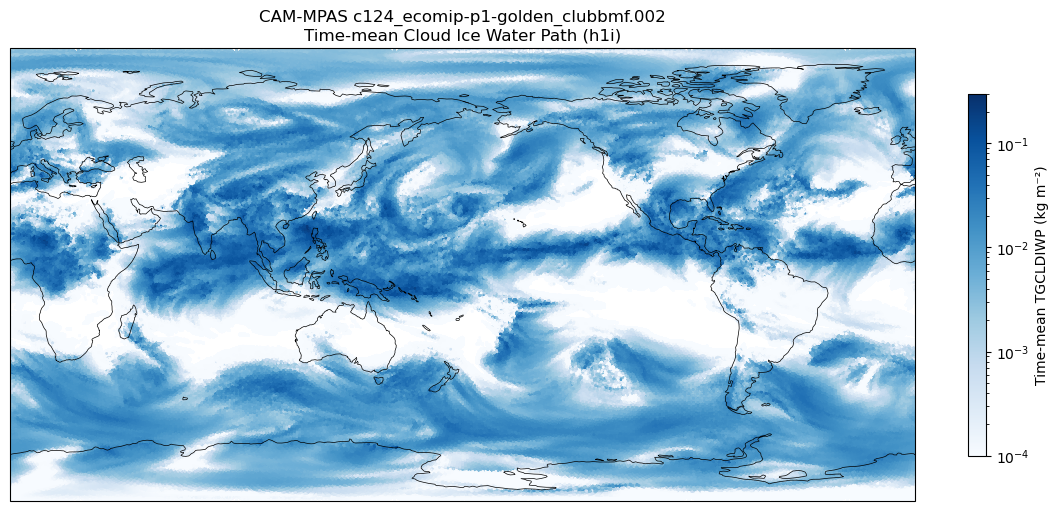

In [5]:
# Time-mean column-integrated cloud ice water path — proxy for deep convection frequency
tgcldiwp_mean = ds_survey["TGCLDIWP"].mean("time").compute()
lat_survey = ds_survey["lat"].isel(time=0).values
lon_survey = ds_survey["lon"].isel(time=0).values  # 0–360

fig, ax = plt.subplots(
    figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
    constrained_layout=True,
)
ax.set_global()
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
sc = ax.scatter(
    lon_survey - 360 * (lon_survey > 180),  # convert to -180..180 for PlateCarree
    lat_survey,
    c=tgcldiwp_mean.values,
    s=0.5,
    cmap="Blues",
    norm=mcolors.LogNorm(vmin=1e-4, vmax=0.3),
    transform=ccrs.PlateCarree(),
    rasterized=True,
)
fig.colorbar(sc, ax=ax, label="Time-mean TGCLDIWP (kg m\u207b\u00b2)", shrink=0.8)
ax.set_title(f"CAM-MPAS {CASE}\nTime-mean Cloud Ice Water Path ({SURVEY_STREAM})")
plt.show()


In [6]:
# Find the time steps and locations with the highest column-integrated ice (deep convection proxy)
print(f"Scanning {len(ds_survey.time)} timesteps in {SURVEY_STREAM} for peak TGCLDIWP ...")
tgcldiwp = ds_survey["TGCLDIWP"].compute()   # shape: (time, ncol)
lat_survey = ds_survey["lat"].isel(time=0).values
lon_survey = ds_survey["lon"].isel(time=0).values

# Restrict to a latitude band where tropical/subtropical deep convection occurs
lat_mask = (lat_survey > -5) & (lat_survey < 35)

# For each timestep, find the max TGCLDIWP cell and its location
records = []
for t_idx in range(len(ds_survey.time)):
    vals = tgcldiwp.isel(time=t_idx).values
    vals_masked = np.where(lat_mask, vals, 0)
    best_col = np.argmax(vals_masked)
    records.append({
        "time": str(ds_survey.time.isel(time=t_idx).values)[:16],
        "lat": lat_survey[best_col],
        "lon": lon_survey[best_col],
        "TGCLDIWP": vals[best_col],
    })

# Sort by TGCLDIWP descending and show top 15
records.sort(key=lambda r: r["TGCLDIWP"], reverse=True)
print(f"{'Rank':<5} {'Time':<18} {'Lat':>7} {'Lon':>8} {'TGCLDIWP (kg/m\u00b2)':>18}")
print("-" * 60)
for rank, r in enumerate(records[:15], 1):
    print(f"{rank:<5} {r['time']:<18} {r['lat']:>7.1f} {r['lon']:>8.1f} {r['TGCLDIWP']:>18.4f}")
print(f"\nTip: set TARGET_DATE, TARGET_SECONDS, LON_CENTER in Cell 1 from a row above,"
      f" then re-run from Cell 9.")
print(f"Note: valid TARGET_SECONDS values come from {SNAPSHOT_STREAM} filenames "
      f"(e.g. {snapshot_files[0].name.split('.')[-2].split('-')[-1]} = "
      f"{int(snapshot_files[0].name.split('.')[-2].split('-')[-1])} s).")


Scanning 96 timesteps in h1i for peak TGCLDIWP ...


Rank  Time                   Lat      Lon   TGCLDIWP (kg/m²)
------------------------------------------------------------
1     2024-09-02 10:30      20.9     40.6            14.2497
2     2024-09-02 23:30      20.8    283.1            14.1821
3     2024-09-02 12:00      20.3     41.1            13.6406
4     2024-09-02 13:30      34.6    359.7            13.5428
5     2024-09-02 16:00      34.6     72.0            13.5356
6     2024-09-03 11:30      15.7     43.5            13.5188
7     2024-09-02 15:00      34.5    359.4            13.4667
8     2024-09-02 10:00      30.2    111.4            13.3056
9     2024-09-03 13:30      19.2     42.0            12.8096
10    2024-09-02 14:00      34.6    359.6            12.5012
11    2024-09-02 18:30      18.1    292.1            12.4473
12    2024-09-03 10:30      15.5     43.6            12.2873
13    2024-09-03 07:30      30.9    121.4            12.2508
14    2024-09-03 13:00      13.6     44.2            12.2029
15    2024-09-03 12:30  

## Target Event Selection

Based on the storm survey above, update the configuration values in **Cell 1** (the top of the notebook)
to point the cross-section at a strong convective event:

- `TARGET_DATE` — date string matching an h1i file, e.g. `"2016-08-15"`
- `TARGET_SECONDS` — seconds-since-midnight offset (3-hourly: 10800, 21600, 32400, 43200, 54000, 64800, 75600, 86400)
- `LON_CENTER` — longitude of the storm in 0–360 convention
- `LON_HALF_WIDTH` — half-width of the longitude slice in degrees (default 2.0; widen to ~5 if too few cells appear)
- `LAT_RANGE` — (south, north) latitude bounds to display

After updating Cell 1, re-run from this cell onward. The defaults below are a starting point.

In [7]:
print("Current cross-section configuration:")
print(f"  Case:         {CASE}")
print(f"  Date/time:    {TARGET_DATE} + {TARGET_SECONDS} s ({TARGET_SECONDS//3600:02d}:00 UTC)")
print(f"  Longitude:    {LON_CENTER:.1f}\u00b0 \u00b1 {LON_HALF_WIDTH:.1f}\u00b0")
print(f"  Latitude:     {LAT_RANGE[0]}\u00b0N \u2013 {LAT_RANGE[1]}\u00b0N")
print(f"  Alt cap:      {ALT_MAX/1000:.0f} km")
print()
print("Tip: update TARGET_DATE, TARGET_SECONDS, LON_CENTER in Cell 1 and re-run from here.")

Current cross-section configuration:
  Case:         c124_ecomip-p1-golden_clubbmf.002
  Date/time:    2024-09-03 + 41400 s (11:00 UTC)
  Longitude:    43.5° ± 2.0°
  Latitude:     5°N – 35°N
  Alt cap:      18 km

Tip: update TARGET_DATE, TARGET_SECONDS, LON_CENTER in Cell 1 and re-run from here.


## Load 3D Snapshot

Load a single h1i file for the selected date and time. These files are large (~929 MB each),
so we open the dataset lazily and only load the variables we need.

**Memory tip:** do NOT call `.compute()` on the full dataset. Instead, apply spatial subsetting
(the longitude band mask) before computing, so only the needed columns are brought into RAM.

In [8]:
snap_match = sorted(case_root.glob(
    f"{CASE}.cam.{SNAPSHOT_STREAM}.{TARGET_DATE}-{TARGET_SECONDS:05d}.nc"
))
if not snap_match:
    raise FileNotFoundError(
        f"No {SNAPSHOT_STREAM} file found for {TARGET_DATE}-{TARGET_SECONDS:05d}.\n"
        f"Valid seconds offsets: "
        f"{sorted(set(f.name.split('.')[-2].split('-')[-1] for f in snapshot_files[:8]))}"
    )

snap_path = snap_match[0]
print(f"Loading: {snap_path.name}")

# Load lazily — do NOT .compute() yet on the full file
vars_3d = ["CLDLIQ", "CLDICE", "Z3", "T"]
ds = xr.open_dataset(snap_path, engine="netcdf4")
ds = ds[vars_3d + ["lat", "lon", "lev", "ilev", "areawt"]]

print(f"\nDimensions: {dict(ds.sizes)}")
print(f"lev: {ds.lev.values[-1]:.0f} m (surface) \u2192 {ds.lev.values[0]:.0f} m (top)")
print(f"ilev: {ds.ilev.values[-1]:.0f} m \u2192 {ds.ilev.values[0]:.0f} m ({len(ds.ilev)} interfaces)")


Loading: c124_ecomip-p1-golden_clubbmf.002.cam.h0i.2024-09-03-41400.nc

Dimensions: {'time': 1, 'lev': 58, 'ncol': 41943042, 'ilev': 59}
lev: 35 m (surface) → 41116 m (top)
ilev: 0 m → 43431 m (59 interfaces)


In [9]:
# Load just the lat/lon (1D, fast) to confirm coverage
lat_all = ds["lat"].values   # shape: (ncol,)
lon_all = ds["lon"].values   # 0–360

print(f"Grid: {len(lat_all)} cells")
print(f"lat: {lat_all.min():.1f}\u00b0 to {lat_all.max():.1f}\u00b0")
print(f"lon: {lon_all.min():.1f}\u00b0 to {lon_all.max():.1f}\u00b0 (0\u2013360 convention)")
print()

# Sample CLDLIQ/CLDICE from a small slice to verify values without loading everything
sample = ds[["CLDLIQ", "CLDICE"]].isel(time=0, lev=slice(30, 40), ncol=slice(0, 1000))
for v in ["CLDLIQ", "CLDICE"]:
    arr = sample[v].values
    nonzero = arr[arr > 0]
    if len(nonzero):
        print(f"{v}: max={arr.max():.2e}, 99th pct of nonzero={np.percentile(nonzero, 99):.2e}")
    else:
        print(f"{v}: all zero in this sample slice")
del sample

Grid: 41943042 cells
lat: -90.0° to 90.0°
lon: 0.0° to 360.0° (0–360 convention)

CLDLIQ: max=4.34e-04, 99th pct of nonzero=2.71e-04
CLDICE: max=4.86e-05, 99th pct of nonzero=2.46e-05


## Overview Map

Plot the column-integrated cloud ice for the selected 3D snapshot to confirm the location
and intensity of deep convective storms before extracting the vertical cross-section.

The red dashed line marks the chosen cross-section longitude. If UXarray is available and
the ESMF mesh file is readable, a native-grid polygon map is produced; otherwise a scatter
plot fallback is used.

/glade/u/home/brianpm/miniconda3/envs/p12/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:258: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


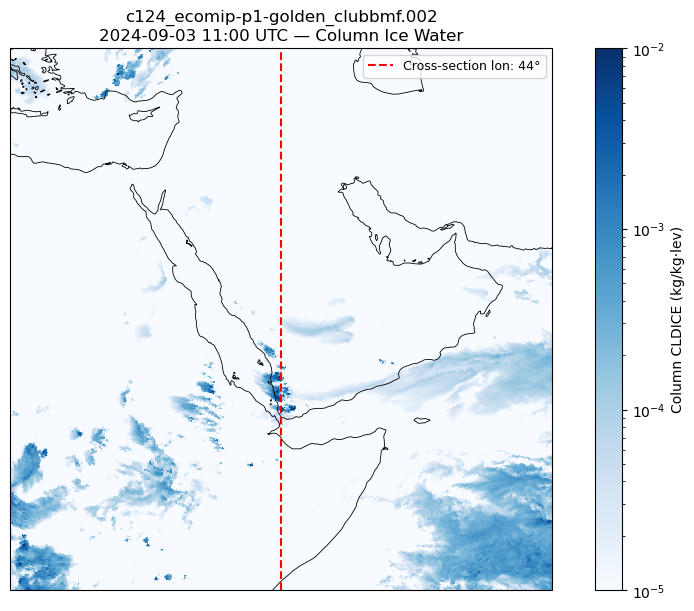

In [10]:
# Use UXarray for the native-grid overview map
# This is the only place we use UXarray; the curtain extraction uses plain numpy

# Convert LON_CENTER from 0-360 to -180/180 convention for display and UXarray bounding box
_lon_c180 = ((LON_CENTER + 180) % 360) - 180

try:
    uxds_snap = ux.open_dataset(str(GRID_FILE), str(snap_path))
    # Column-integrated ice path for overview
    cice_col = ds["CLDICE"].isel(time=0).sum("lev").values  # shape: (ncol,)

    # Build a UxDataArray for plotting using the existing grid
    ux_cice = ux.UxDataArray(
        data=cice_col,
        dims=["n_face"],
        uxgrid=uxds_snap.uxgrid,
        name="CLDICE_col",
    )

    # Bounding box for overview — UXarray uses -180/180 convention internally
    overview_lon = (_lon_c180 - 20, _lon_c180 + 20)
    overview_lat = (LAT_RANGE[0] - 5, LAT_RANGE[1] + 5)

    ux_cice_bbox = ux_cice.subset.bounding_box(overview_lon, overview_lat)
    pc_overview = ux_cice_bbox.to_polycollection()
    pc_overview.set_antialiased(False)
    ice_norm_ov = mcolors.LogNorm(vmin=1e-5, vmax=1e-2)
    pc_overview.set_norm(ice_norm_ov)
    pc_overview.set_cmap("Blues")

    fig, ax = plt.subplots(
        figsize=(10, 6),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )
    ax.set_xlim([_lon_c180 - 20, _lon_c180 + 20])
    ax.set_ylim(overview_lat)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)
    ax.add_collection(pc_overview)
    cb = fig.colorbar(pc_overview, ax=ax, label="Column CLDICE (kg/kg\u00b7lev)")
    # Mark the cross-section longitude
    ax.axvline(x=_lon_c180, color="red", linewidth=1.5, linestyle="--",
               label=f"Cross-section lon: {LON_CENTER:.0f}\u00b0")
    ax.legend(loc="upper right", fontsize=9)
    ax.set_title(f"{CASE}\n{TARGET_DATE} {TARGET_SECONDS//3600:02d}:00 UTC \u2014 Column Ice Water")
    plt.show()

except Exception as e:
    print(f"UXarray overview skipped ({e}). Falling back to scatter plot.")
    cice_col = ds["CLDICE"].isel(time=0).sum("lev").values
    lon180 = lon_all - 360 * (lon_all > 180)
    near = ((np.abs(lon180 - _lon_c180) < 25) &
            (lat_all > LAT_RANGE[0] - 5) & (lat_all < LAT_RANGE[1] + 5))
    fig, ax = plt.subplots(
        figsize=(10, 6),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )
    ax.set_xlim([_lon_c180 - 25, _lon_c180 + 25])
    ax.set_ylim([LAT_RANGE[0] - 5, LAT_RANGE[1] + 5])
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    sc = ax.scatter(lon180[near], lat_all[near], c=cice_col[near], s=1,
                    cmap="Blues", norm=mcolors.LogNorm(vmin=1e-5, vmax=1e-2),
                    transform=ccrs.PlateCarree(), rasterized=True)
    fig.colorbar(sc, ax=ax, label="Column CLDICE (kg/kg\u00b7lev)")
    ax.axvline(x=_lon_c180, color="red", linewidth=1.5, linestyle="--")
    ax.set_title(f"{CASE} \u2014 Column Ice Water (scatter fallback)")
    plt.show()


## Vertical Cross Section: Extract Curtain

Algorithm:
1. Select all MPAS columns whose longitude falls within `LON_CENTER ± LON_HALF_WIDTH` and
   whose latitude falls within `LAT_RANGE`. A date-line–safe shift is applied before the
   longitude comparison.
2. Extract CLDLIQ, CLDICE, Z3, and T for only those columns (small arrays — safe to load).
3. Sort columns by latitude so the x-axis runs south → north.
4. Build pcolormesh boundary arrays: `ilev` (59 interface heights) for the y-axis and
   midpoint-interpolated latitude bounds for the x-axis.
5. Replace exact zeros with NaN so that log-scale colormaps skip cloud-free cells.

In [11]:
# ── 1. Select cells in the longitude band ────────────────────────────────────
lon_norm = lon_all % 360
lon_c = LON_CENTER % 360

# Handle date-line wrap: if lon_c is near 0 or 360, the simple range check fails
# For safety, shift so lon_c is near 180 and do the comparison
shift = 180.0 - lon_c
lon_shifted = (lon_norm + shift) % 360
center_shifted = 180.0

cell_mask = (
    (np.abs(lon_shifted - center_shifted) < LON_HALF_WIDTH) &
    (lat_all > LAT_RANGE[0]) &
    (lat_all < LAT_RANGE[1])
)

n_cells = cell_mask.sum()
print(f"Cells in cross-section band: {n_cells}  "
      f"(lon {LON_CENTER:.1f}\u00b0\u00b1{LON_HALF_WIDTH:.1f}\u00b0, lat {LAT_RANGE[0]}\u2013{LAT_RANGE[1]}\u00b0N)")
if n_cells < 10:
    print("WARNING: very few cells \u2014 consider widening LON_HALF_WIDTH")

# ── 2. Extract subset and compute (small array, safe to load) ─────────────────
lat_sub = lat_all[cell_mask]

# Use numpy indexing to avoid loading full file
# ds variables have shape (time=1, lev=58, ncol=40962)
cldliq_raw = ds["CLDLIQ"].isel(time=0).values[:, cell_mask]   # (lev, ncol_sub)
cldice_raw = ds["CLDICE"].isel(time=0).values[:, cell_mask]
z3_raw     = ds["Z3"].isel(time=0).values[:, cell_mask]
t_raw      = ds["T"].isel(time=0).values[:, cell_mask]

print(f"Extracted arrays: shape = {cldliq_raw.shape}  (lev, ncol_sub)")
print(f"CLDLIQ: max = {cldliq_raw.max():.2e} kg/kg")
print(f"CLDICE: max = {cldice_raw.max():.2e} kg/kg")

# ── 3. Sort columns by latitude (left = south, right = north) ─────────────────
sidx = np.argsort(lat_sub)
lat_s    = lat_sub[sidx]
cldliq_s = cldliq_raw[:, sidx]   # (58, ncol_sub)
cldice_s = cldice_raw[:, sidx]
z3_s     = z3_raw[:, sidx]
t_s      = t_raw[:, sidx]

# ── 4. Mask true zeros (no cloud) for cleaner log-scale plots ─────────────────
cldliq_plot = np.where(cldliq_s > 0, cldliq_s, np.nan)
cldice_plot = np.where(cldice_s > 0, cldice_s, np.nan)

# ── 5. Build pcolormesh boundary coordinates ──────────────────────────────────
# y-axis: use ilev (interface heights, 59 values) — one per cell boundary
ilev_vals = ds["ilev"].values  # (59,), top-to-bottom like lev

# x-axis: latitude boundaries (midpoints between adjacent cell centers)
if len(lat_s) > 1:
    lat_b = np.concatenate([
        [lat_s[0]  - 0.5 * (lat_s[1]  - lat_s[0])],
        0.5 * (lat_s[:-1] + lat_s[1:]),
        [lat_s[-1] + 0.5 * (lat_s[-1] - lat_s[-2])],
    ])
else:
    lat_b = np.array([lat_s[0] - LON_HALF_WIDTH, lat_s[0] + LON_HALF_WIDTH])

# Create 2D boundary meshgrid: shape (59, ncol_sub+1)
lat_2d, ilev_2d = np.meshgrid(lat_b, ilev_vals)

print(f"\nBoundary grid shape: lat_2d={lat_2d.shape}, ilev_2d={ilev_2d.shape}")
print(f"Data shape (lev, ncol): {cldliq_s.shape}  \u2014 should be (N-1, M-1) relative to boundaries")

Cells in cross-section band: 111797  (lon 43.5°±2.0°, lat 5–35°N)
Extracted arrays: shape = (58, 111797)  (lev, ncol_sub)
CLDLIQ: max = 5.52e-03 kg/kg
CLDICE: max = 1.67e-02 kg/kg

Boundary grid shape: lat_2d=(59, 111798), ilev_2d=(59, 111798)
Data shape (lev, ncol): (58, 111797)  — should be (N-1, M-1) relative to boundaries


## Curtain Plot: Cloud Liquid and Ice

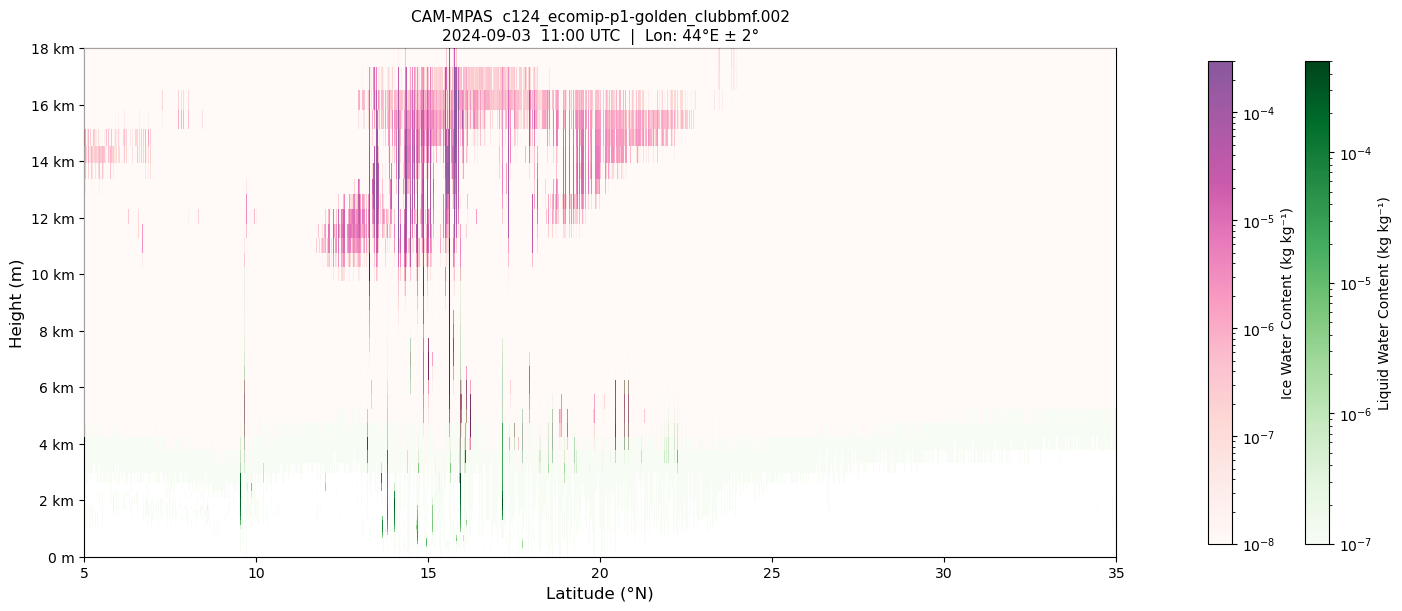

In [12]:
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

# ── Cloud liquid water (green) ─────────────────────────────────────────────
liq_norm = mcolors.LogNorm(vmin=1e-7, vmax=5e-4)
im_liq = ax.pcolormesh(
    lat_2d, ilev_2d, cldliq_plot,
    cmap="Greens",
    norm=liq_norm,
    shading="flat",
    zorder=2,
)

# ── Cloud ice water (pink/purple) — overlaid with alpha ────────────────────
ice_norm = mcolors.LogNorm(vmin=1e-8, vmax=3e-4)
im_ice = ax.pcolormesh(
    lat_2d, ilev_2d, cldice_plot,
    cmap="RdPu",
    norm=ice_norm,
    shading="flat",
    alpha=0.65,
    zorder=3,
)

# ── Axes formatting ───────────────────────────────────────────────────────
ax.set_xlim(LAT_RANGE)
ax.set_ylim(0, ALT_MAX)
ax.set_xlabel("Latitude (\u00b0N)", fontsize=12)
ax.set_ylabel("Height (m)", fontsize=12)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f} km" if x >= 1000 else f"{x:.0f} m"))

title_lon = f"{abs(LON_CENTER - 360):.0f}\u00b0W" if LON_CENTER > 180 else f"{LON_CENTER:.0f}\u00b0E"
ax.set_title(
    f"CAM-MPAS  {CASE}\n"
    f"{TARGET_DATE}  {TARGET_SECONDS//3600:02d}:00 UTC  |  "
    f"Lon: {title_lon} \u00b1 {LON_HALF_WIDTH:.0f}\u00b0",
    fontsize=11,
)

# ── Colorbars ─────────────────────────────────────────────────────────────
cb_liq = fig.colorbar(im_liq, ax=ax, location="right", pad=0.01, shrink=0.95,
                       label="Liquid Water Content (kg kg\u207b\u00b9)")
cb_ice = fig.colorbar(im_ice, ax=ax, location="right", pad=0.08, shrink=0.95,
                       label="Ice Water Content (kg kg\u207b\u00b9)")

plt.show()

## Tropopause Reference

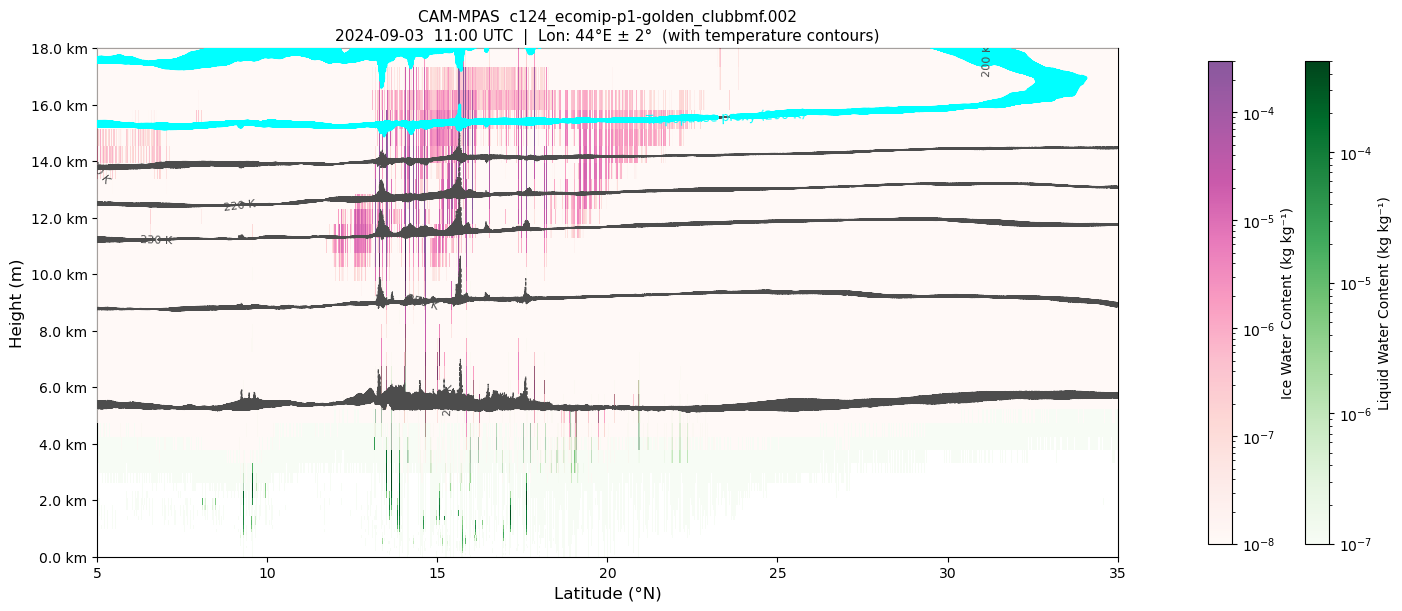

In [13]:
# Re-make the curtain plot with temperature reference lines overlaid
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

im_liq = ax.pcolormesh(lat_2d, ilev_2d, cldliq_plot,
                        cmap="Greens", norm=liq_norm, shading="flat", zorder=2)
im_ice = ax.pcolormesh(lat_2d, ilev_2d, cldice_plot,
                        cmap="RdPu", norm=ice_norm, shading="flat", alpha=0.65, zorder=3)

# ── Temperature contours (use cell-center coords) ──────────────────────────
# z3_s: actual geopotential height (varies by column) — use as y for contour
# lat_s: cell-center latitudes
lat_c2d, z3_c2d = np.meshgrid(lat_s, ds["lev"].values[::-1])  # bottom-to-top for z3
# Actually use z3_s directly (shape: lev x ncol_sub)
# pcolormesh uses boundaries; contour uses centers — use lat_s and z3_s
ct = ax.contour(
    np.tile(lat_s, (len(ds["lev"]), 1)),  # shape (lev, ncol_sub)
    z3_s,                                  # actual geopotential heights
    t_s,
    levels=[200, 210, 220, 230, 250, 270],
    colors="0.3",
    linewidths=0.7,
    linestyles="--",
    zorder=4,
)
ax.clabel(ct, inline=True, fontsize=8, fmt="%d K")

# Mark approximate tropopause using T=200K isotherm (tropical tropopause ~16–17 km)
ct_trop = ax.contour(
    np.tile(lat_s, (len(ds["lev"]), 1)),
    z3_s,
    t_s,
    levels=[200],
    colors="cyan",
    linewidths=2.0,
    linestyles="-",
    zorder=5,
)
ax.clabel(ct_trop, inline=True, fontsize=9, fmt="Tropopause proxy (200 K)")

# ── Axes ──────────────────────────────────────────────────────────────────
ax.set_xlim(LAT_RANGE)
ax.set_ylim(0, ALT_MAX)
ax.set_xlabel("Latitude (\u00b0N)", fontsize=12)
ax.set_ylabel("Height (m)", fontsize=12)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.1f} km"))

ax.set_title(
    f"CAM-MPAS  {CASE}\n"
    f"{TARGET_DATE}  {TARGET_SECONDS//3600:02d}:00 UTC  |  "
    f"Lon: {title_lon} \u00b1 {LON_HALF_WIDTH:.0f}\u00b0  (with temperature contours)",
    fontsize=11,
)
fig.colorbar(im_liq, ax=ax, location="right", pad=0.01, shrink=0.95,
             label="Liquid Water Content (kg kg\u207b\u00b9)")
fig.colorbar(im_ice, ax=ax, location="right", pad=0.08, shrink=0.95,
             label="Ice Water Content (kg kg\u207b\u00b9)")

plt.show()

## Notes on Interpretation

- The x-axis shows all MPAS cells within the lon band, sorted by latitude. Cell widths reflect
  the Voronoi cell spacing (~3.75 km at this resolution).
- The y-axis is height in meters. Unlike conventional CAM, this model uses height-based vertical
  coordinates — no pressure interpolation is needed.
- Green = liquid water (low-level clouds, warm rain). Pink/purple = ice water (cirrus, deep
  convective anvils, and convective cores).
- Tall narrow ice towers indicate active deep convection. Check whether they reach the cyan
  T = 200 K tropopause line.
- Re-run from Cell 16 with a different `LON_CENTER` to survey the storm over a wider area.

## (Optional) Time Series: Storm Evolution

In [14]:
# Uncomment to generate a series of curtain plots across multiple h1i snapshots
# showing storm evolution. WARNING: each h1i file is ~929 MB, so only load
# the subset (cell_mask) — do NOT open them all with open_mfdataset.

# target_snaps = [
#     ("2016-08-01", 10800),
#     ("2016-08-01", 21600),
#     ("2016-08-01", 32400),
# ]
# fig, axes = plt.subplots(len(target_snaps), 1,
#                          figsize=(14, 5 * len(target_snaps)),
#                          constrained_layout=True, sharex=True, sharey=True)
# for ax_i, (tdate, tsec) in zip(axes, target_snaps):
#     snap_path = sorted(case_root.glob(f"{CASE}.cam.h1i.{tdate}-{tsec:05d}.nc"))
#     if not snap_path:
#         ax_i.set_title(f"Missing: {tdate}-{tsec:05d}")
#         continue
#     ds_i = xr.open_dataset(snap_path[0], engine="netcdf4")
#     cl_i = ds_i["CLDLIQ"].isel(time=0).values[:, cell_mask][:, sidx]
#     ci_i = ds_i["CLDICE"].isel(time=0).values[:, cell_mask][:, sidx]
#     cl_i = np.where(cl_i > 0, cl_i, np.nan)
#     ci_i = np.where(ci_i > 0, ci_i, np.nan)
#     ax_i.pcolormesh(lat_2d, ilev_2d, cl_i, cmap="Greens", norm=liq_norm, shading="flat")
#     ax_i.pcolormesh(lat_2d, ilev_2d, ci_i, cmap="RdPu", norm=ice_norm,
#                     shading="flat", alpha=0.65)
#     ax_i.set_ylim(0, ALT_MAX)
#     ax_i.set_xlim(LAT_RANGE)
#     ax_i.set_ylabel("Height (m)")
#     ax_i.set_title(f"{tdate}  {tsec//3600:02d}:00 UTC")
#     ds_i.close()
# axes[-1].set_xlabel("Latitude (\u00b0N)")
# plt.show()
print("Uncomment the code above to generate a time series of curtain plots.")

Uncomment the code above to generate a time series of curtain plots.
